In [46]:
import numpy as np
import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt

from utils import ff_nn, coords_2_strain_nn
from utils_hyperelasticity import NODE, NODE_model_iso, ThreeDElasticity, split_c_s_params_iso, merge_c_s_params_iso
from jax.flatten_util import ravel_pytree
from jax_fem.generate_mesh import get_meshio_cell_type, Mesh, rectangle_mesh
from fem import plotmesh
from jax import jit, vmap, grad, jacrev

In [40]:
def coords_2_disp_x(X,Y,t,params):
    inp = jnp.stack([X,Y,t])[None,:]
    out = coords_2_strain_nn(inp, params)
    t = t.astype(int)
    return out[0,0]*disps_x_stdv[t] + disps_x_mean[t]
def coords_2_disp_y(X,Y,t,params):
    inp = jnp.stack([X,Y,t])[None,:]
    out = coords_2_strain_nn(inp, params)
    t = t.astype(int)
    return out[0,1]*disps_y_stdv[t] + disps_y_mean[t]

def F_xx_fn(inp,params):
    return grad(coords_2_disp_x           )(inp[0], inp[1], inp[2], params) + 1.0
def F_yy_fn(inp,params):
    return grad(coords_2_disp_y, argnums=1)(inp[0], inp[1], inp[2], params) + 1.0
def F_yx_fn(inp,params):
    return grad(coords_2_disp_y           )(inp[0], inp[1], inp[2], params)
def F_xy_fn(inp,params):
    return grad(coords_2_disp_x, argnums=1)(inp[0], inp[1], inp[2], params)

coords_2_strain_nn2 = vmap(lambda inp, params: jnp.stack([F_xx_fn(inp, params), F_xy_fn(inp, params), F_yx_fn(inp, params), F_yy_fn(inp,params)]), in_axes=(0, None))

### Displacement contours (data)

In [85]:
with open('data/manu/stiff2_hetero_disp.npy', 'rb') as f:
    x,y,ux_hist,uy_hist = pickle.load(f)
i1 = 10
i2 = None
skip = 30
ux_hist = jnp.array(ux_hist[i1:i2:skip])
uy_hist = jnp.array(uy_hist[i1:i2:skip])

skip2 = 5
x = x[::skip2, ::skip2]
y = y[::skip2, ::skip2]
ux_hist = ux_hist[:,::skip2,::skip2]
uy_hist = uy_hist[:,::skip2,::skip2]

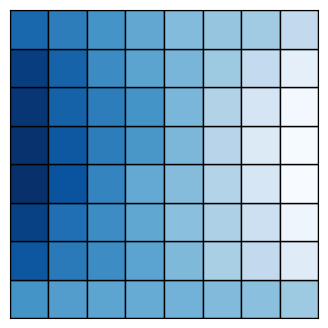

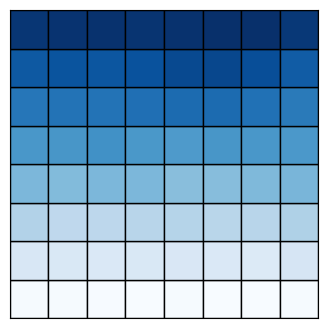

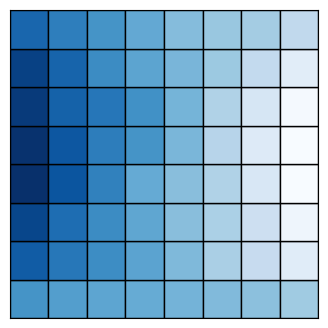

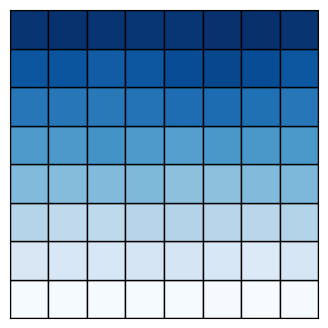

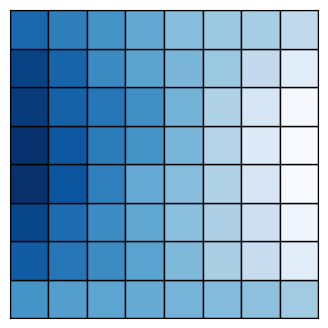

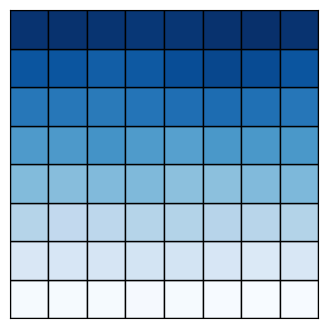

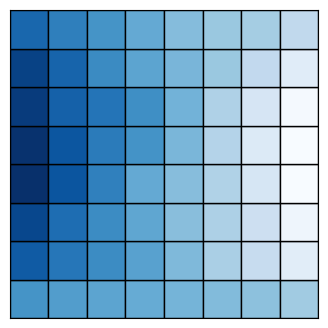

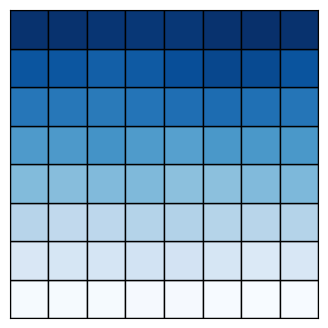

In [87]:
x = x

ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = x.shape[0], x.shape[1]
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])

for i in range(4):
    fig, ax = plt.subplots(figsize=(5,4))
    plotmesh(mesh.cells, mesh.points, ux_hist[i].flatten(), title=None, ax=ax, cbar=False); 
    ax.set(xlim=(0,1),ylim=(0,1))
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    fig.savefig('figs/fig_architecture/ux' + str(i) + '_gt.pdf', bbox_inches='tight', pad_inches=0)

    fig, ax = plt.subplots(figsize=(5,4))
    plotmesh(mesh.cells, mesh.points, uy_hist[i].flatten(), title=None, ax=ax, cbar=False); 
    ax.set(xlim=(0,1),ylim=(0,1))
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    fig.savefig('figs/fig_architecture/uy' + str(i) + '_gt.pdf', bbox_inches='tight', pad_inches=0)

### Displacement contours (predictions)

In [44]:
with open('data/manu/stiff2_hetero_disp.npy', 'rb') as f:
    x,y,ux_hist,uy_hist = pickle.load(f)
with open('data/manu/temp.npy', 'rb') as f:
    E_hist_dic = pickle.load(f)

x1 = 4
x2 = 42
y1 = 2
y2 = 40
out = []
for aux in E_hist_dic:
    out.append(aux.transpose([2,0,1]).reshape([42,43,2,2]).transpose([1,0,2,3])[x1:x2,y1:y2,:,:].reshape([-1,2,2])) # I know. wtf?
E_hist_dic = np.array(out)
elem_X = np.stack([x.flatten(),y.flatten()]).T

i1 = 10
i2 = None
skip = 30
ux_hist = jnp.array(ux_hist[i1:i2:skip])
uy_hist = jnp.array(uy_hist[i1:i2:skip])
E_hist_dic = E_hist_dic[i1:i2:skip]


with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, \
                 bd_X, t_hist, disps_x_mean, disps_x_stdv, disps_y_mean, disps_y_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params_iso(node_params)
_, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_iso(merge_c_s_params_iso(common_params, unravel(params)))

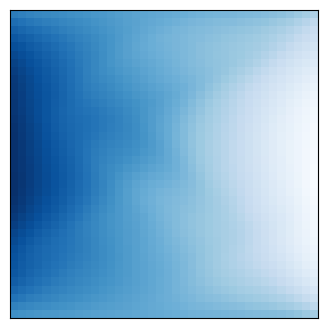

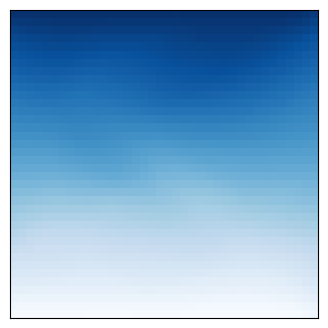

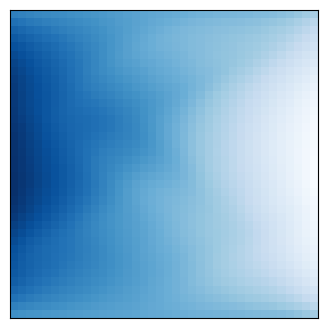

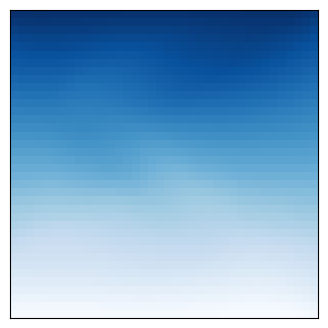

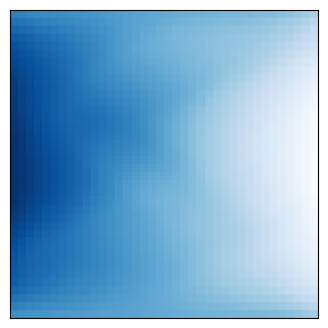

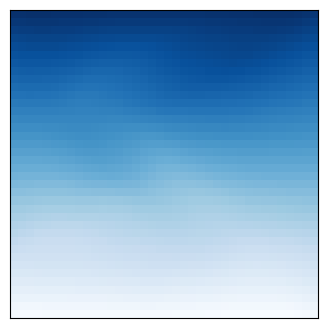

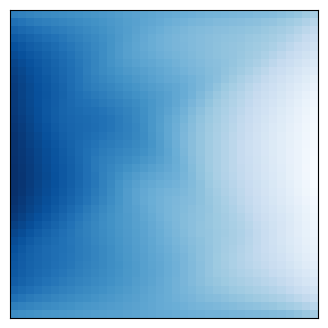

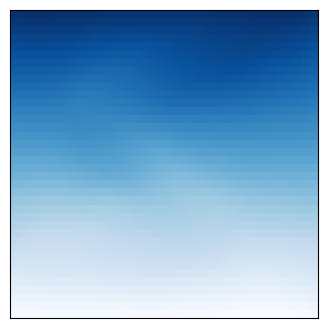

In [68]:
for t in range(4):
    disp_x = vmap(coords_2_disp_x, in_axes=(0,0,0,None))(elem_X[:,0], elem_X[:,1], t*np.ones_like(elem_X[:,0]), coord_2_strain_params)
    disp_y = vmap(coords_2_disp_y, in_axes=(0,0,0,None))(elem_X[:,0], elem_X[:,1], t*np.ones_like(elem_X[:,0]), coord_2_strain_params)
    
    fig, ax = plt.subplots(figsize=(5,4))
    plotmesh(mesh.cells, mesh.points, disp_x, title=None, ax=ax, ec='None', cbar=False); 
    ax.set(xlim=(0,1),ylim=(0,1))
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    fig.savefig('figs/fig_architecture/ux' + str(t) + '_pr.pdf', bbox_inches='tight', pad_inches=0)
    

    fig, ax = plt.subplots(figsize=(5,4))
    plotmesh(mesh.cells, mesh.points, disp_y, title=None, ax=ax, ec='None', cbar=False); 
    ax.set(xlim=(0,1),ylim=(0,1))
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    fig.savefig('figs/fig_architecture/uy' + str(t) + '_pr.pdf', bbox_inches='tight', pad_inches=0)

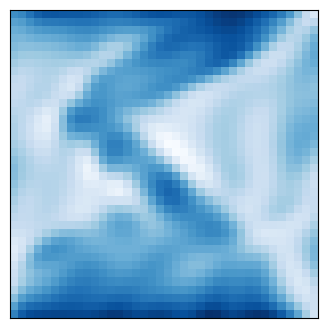

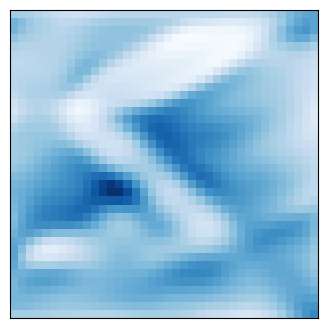

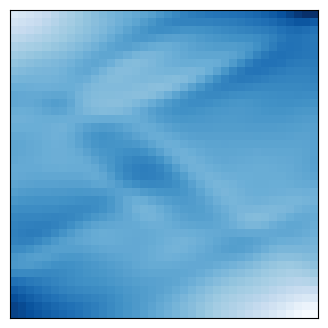

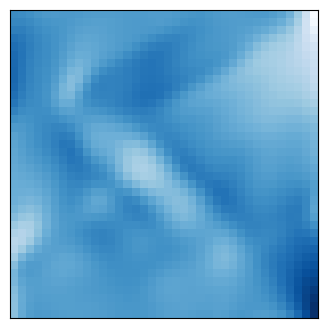

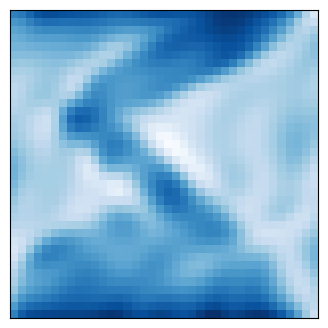

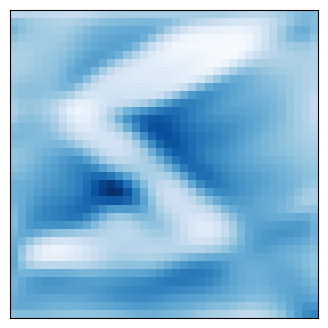

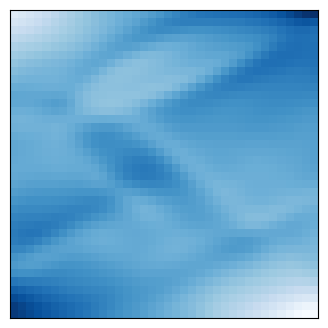

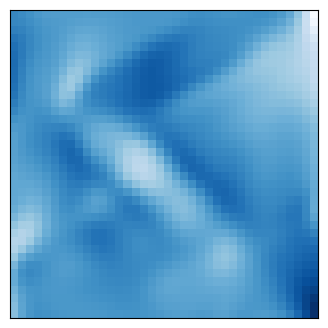

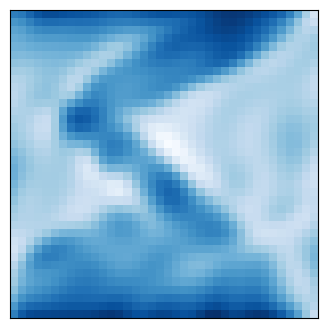

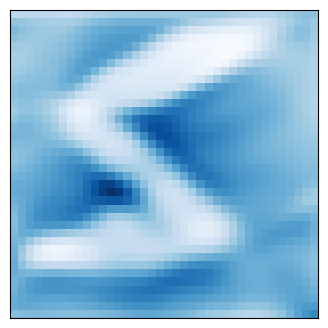

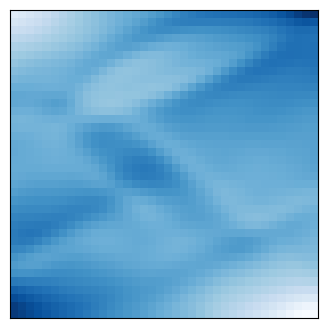

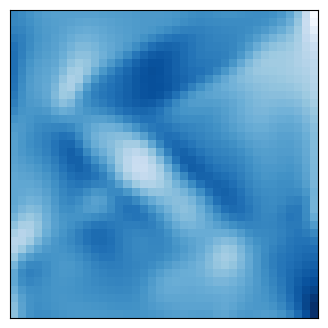

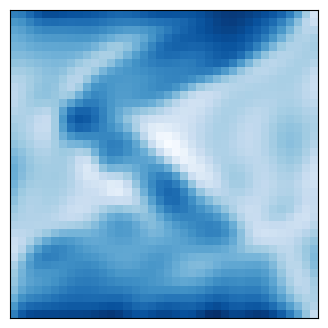

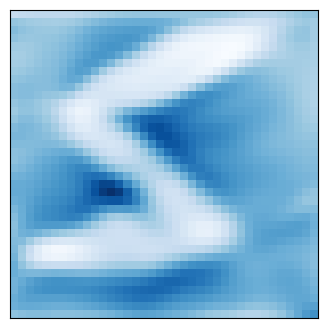

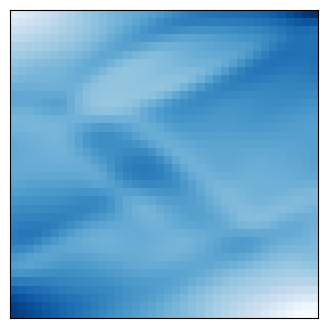

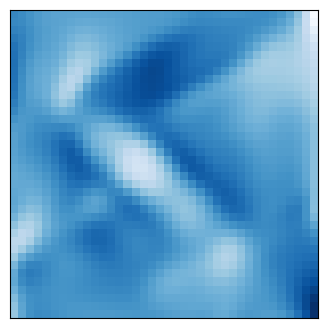

In [70]:
for t in range(4):
    inp = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(inp, coord_2_strain_params).T
    
    fig, ax = plt.subplots(figsize=(5,4))
    plotmesh(mesh.cells, mesh.points, F_xx, title=None, ax=ax, ec='None', cbar=False); 
    ax.set(xlim=(0,1),ylim=(0,1))
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    fig.savefig('figs/fig_architecture/Fxx' + str(t) + '_pr.pdf', bbox_inches='tight', pad_inches=0)

    fig, ax = plt.subplots(figsize=(5,4))
    plotmesh(mesh.cells, mesh.points, F_yy, title=None, ax=ax, ec='None', cbar=False); 
    ax.set(xlim=(0,1),ylim=(0,1))
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    fig.savefig('figs/fig_architecture/Fyy' + str(t) + '_pr.pdf', bbox_inches='tight', pad_inches=0)

    fig, ax = plt.subplots(figsize=(5,4))
    plotmesh(mesh.cells, mesh.points, F_xy, title=None, ax=ax, ec='None', cbar=False); 
    ax.set(xlim=(0,1),ylim=(0,1))
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    fig.savefig('figs/fig_architecture/Fxy' + str(t) + '_pr.pdf', bbox_inches='tight', pad_inches=0)

    fig, ax = plt.subplots(figsize=(5,4))
    plotmesh(mesh.cells, mesh.points, F_yx, title=None, ax=ax, ec='None', cbar=False); 
    ax.set(xlim=(0,1),ylim=(0,1))
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    fig.savefig('figs/fig_architecture/Fyx' + str(t) + '_pr.pdf', bbox_inches='tight', pad_inches=0)